# Notebook 16: Double DQN & Dueling DQN

**Series:** Reinforcement Learning Basics (16/20)

---

## 1. Double DQN

### Problem: Maximization Bias
DQN uses $\max_a Q(s', a; \theta^-)$ — the same network selects and evaluates. This **overestimates** Q-values.

### Solution: Decouple Selection and Evaluation

$$y = r + \gamma Q\Big(s', \underbrace{\arg\max_{a'} Q(s', a'; \theta)}_{\text{online selects}};\; \underbrace{\theta^-}_{\text{target evaluates}}\Big)$$

## 2. Dueling DQN

### Decompose Q into Value + Advantage

$$Q(s, a; \theta) = V(s; \theta_V) + A(s, a; \theta_A)$$

**Network architecture:** Shared feature layers → two streams:
- **Value stream:** scalar $V(s)$
- **Advantage stream:** $A(s, a)$ for each action

### Identifiability Trick
$$Q(s,a) = V(s) + A(s,a) - \frac{1}{|\mathcal{A}|} \sum_{a'} A(s, a')$$

**Why Dueling?** In many states, the value doesn't depend on which action you take. Dueling learns $V(s)$ more efficiently.

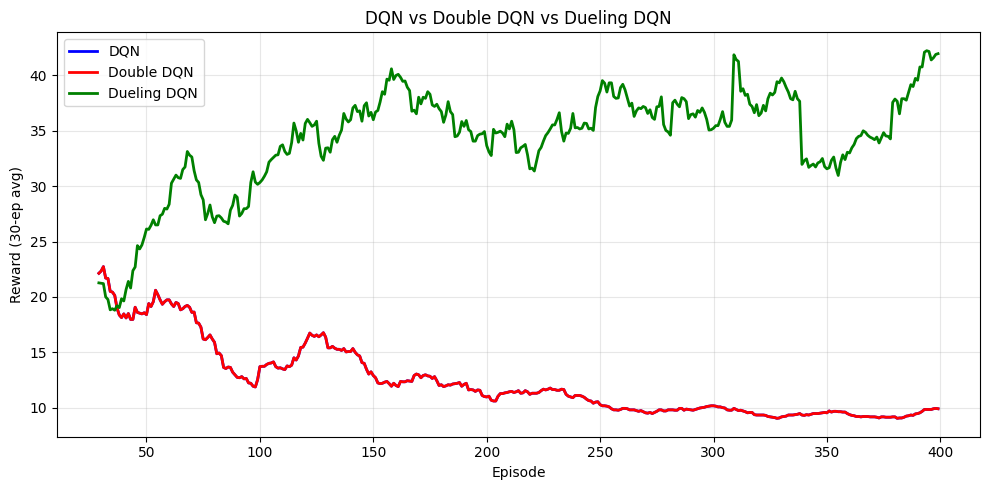

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

# Reuse CartPole and ReplayBuffer from notebook 15
class CartPole:
    def __init__(self):
        self.gravity=9.8;self.masscart=1.0;self.masspole=0.1;self.total_mass=1.1
        self.length=0.5;self.polemass_length=0.05;self.force_mag=10.0;self.tau=0.02
        self.theta_threshold=12*np.pi/180;self.x_threshold=2.4
    def reset(self):
        self.state=np.random.uniform(-0.05,0.05,4);return self.state.copy()
    def step(self,action):
        x,xd,th,thd=self.state;f=self.force_mag if action==1 else -self.force_mag
        ct,st=np.cos(th),np.sin(th)
        tmp=(f+self.polemass_length*thd**2*st)/self.total_mass
        thacc=(self.gravity*st-ct*tmp)/(self.length*(4/3-self.masspole*ct**2/self.total_mass))
        xacc=tmp-self.polemass_length*thacc*ct/self.total_mass
        self.state=np.array([x+self.tau*xd,xd+self.tau*xacc,th+self.tau*thd,thd+self.tau*thacc])
        done=abs(self.state[0])>self.x_threshold or abs(self.state[2])>self.theta_threshold
        return self.state.copy(),1.0 if not done else 0.0,done

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    def push(self, s, a, r, sn, d):
        self.buffer.append((s,a,r,sn,d))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s,a,r,sn,d = zip(*batch)
        return np.array(s),np.array(a),np.array(r),np.array(sn),np.array(d)
    def __len__(self): return len(self.buffer)

class DQNAgent:
    """Configurable: vanilla DQN, Double DQN, or Dueling DQN."""
    def __init__(self, double=False, dueling=False, lr=0.001):
        self.double = double
        self.dueling = dueling
        h = 64
        self.W1 = np.random.randn(4, h)*0.1; self.b1 = np.zeros(h)
        if dueling:
            self.W_v = np.random.randn(h, 1)*0.1; self.b_v = np.zeros(1)
            self.W_a = np.random.randn(h, 2)*0.1; self.b_a = np.zeros(2)
        else:
            self.W2 = np.random.randn(h, 2)*0.1; self.b2 = np.zeros(2)
        self.lr = lr
        # Target copies
        self._copy_params()

    def _copy_params(self):
        self.tW1=self.W1.copy();self.tb1=self.b1.copy()
        if self.dueling:
            self.tW_v=self.W_v.copy();self.tb_v=self.b_v.copy()
            self.tW_a=self.W_a.copy();self.tb_a=self.b_a.copy()
        else:
            self.tW2=self.W2.copy();self.tb2=self.b2.copy()

    def _forward(self, x, target=False):
        W1,b1 = (self.tW1,self.tb1) if target else (self.W1,self.b1)
        h = np.maximum(0, x @ W1 + b1)
        if self.dueling:
            Wv,bv = (self.tW_v,self.tb_v) if target else (self.W_v,self.b_v)
            Wa,ba = (self.tW_a,self.tb_a) if target else (self.W_a,self.b_a)
            v = h @ Wv + bv
            a = h @ Wa + ba
            q = v + a - a.mean(axis=1, keepdims=True)
        else:
            W2,b2 = (self.tW2,self.tb2) if target else (self.W2,self.b2)
            q = h @ W2 + b2
        return q

    def predict(self, state):
        return self._forward(state.reshape(1,-1))[0]

    def get_targets(self, s, a, r, sn, d):
        gamma = 0.99
        if self.double:
            a_best = np.argmax(self._forward(sn, target=False), axis=1)
            q_target = self._forward(sn, target=True)
            q_next = q_target[np.arange(len(sn)), a_best]
        else:
            q_next = np.max(self._forward(sn, target=True), axis=1)
        return r + gamma * q_next * (1 - d)

def train_agent(agent_type, n_episodes=400):
    double = 'double' in agent_type
    dueling = 'dueling' in agent_type
    agent = DQNAgent(double=double, dueling=dueling)
    buf = ReplayBuffer(10000)
    eps = 1.0; rewards = []

    for ep in range(n_episodes):
        env = CartPole(); state = env.reset(); total = 0
        for _ in range(500):
            if np.random.random() < eps:
                action = np.random.randint(2)
            else:
                action = np.argmax(agent.predict(state))
            ns, r, done = env.step(action)
            buf.push(state, action, r, ns, done)
            total += r; state = ns
            if done: break
        eps = max(0.01, eps * 0.995)
        if ep % 10 == 0: agent._copy_params()
        rewards.append(total)
    return rewards

# Compare
np.random.seed(42)
r_dqn = train_agent('vanilla', 400)
np.random.seed(42)
r_ddqn = train_agent('double', 400)
np.random.seed(42)
r_duel = train_agent('dueling', 400)

plt.figure(figsize=(10, 5))
w = 30
for rewards, label, color in [(r_dqn,'DQN','blue'),(r_ddqn,'Double DQN','red'),(r_duel,'Dueling DQN','green')]:
    sm = np.convolve(rewards, np.ones(w)/w, mode='valid')
    plt.plot(range(w-1, len(rewards)), sm, linewidth=2, label=label, color=color)
plt.xlabel('Episode'); plt.ylabel(f'Reward ({w}-ep avg)')
plt.title('DQN vs Double DQN vs Dueling DQN')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

## Summary

| Variant | Key Change | Benefit |
|---------|-----------|---------|
| **Double DQN** | Online selects, target evaluates | Reduces overestimation |
| **Dueling DQN** | $Q = V + A$ decomposition | Better value estimation |

**Next:** Notebook 17 — Experience Replay